## HW4: Probabilistic Clustering and Gaussian Mixture Models

In this lab, we compare k-means and Gaussian Mixture Models (GMM)
on two overlapping Iris species (versicolor and virginica).

We focus on two informative features:
- Petal length
- Petal width

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

sns.set(style='whitegrid')

# Create output directory for figures
os.makedirs('figs_results', exist_ok=True)

## Load Data and Restrict to Two Classes and Select Two Features

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

# Keep only versicolor (1) and virginica (2)
mask = y != 0
X = X[mask]
y = y[mask] - 1  # relabel to 0 and 1

print('Class distribution:', np.bincount(y))

# Select Two Features: petal length (2) and petal width (3)
X = X[:, [2, 3]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)

Class distribution: [50 50]
Feature matrix shape: (100, 2)


# Task 1: k-Means vs Spherical GMM vs full GMM

1. Fit k-means with K=2.
2. Fit a spherical GMM with K=2.
3. Fit a full covariance GMM with K = 2

In [3]:
# Fit models
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

gmm_spherical = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
gmm_sph_labels = gmm_spherical.fit_predict(X_scaled)

gmm_full = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_full_labels = gmm_full.fit_predict(X_scaled)

# ARI Scores
ari_km  = adjusted_rand_score(y, km_labels)
ari_sph = adjusted_rand_score(y, gmm_sph_labels)
ari_full = adjusted_rand_score(y, gmm_full_labels)

print(f'ARI  k-Means          : {ari_km:.4f}')
print(f'ARI  Spherical GMM    : {ari_sph:.4f}')
print(f'ARI  Full-cov GMM     : {ari_full:.4f}')

# Centroids and Means
print('\nk-Means centroids (scaled):')
print(kmeans.cluster_centers_)

print('\nSpherical GMM component means (scaled):')
print(gmm_spherical.means_)

print('\nFull-cov GMM component means (scaled):')
print(gmm_full.means_)

ARI  k-Means          : 0.7721
ARI  Spherical GMM    : 0.7721
ARI  Full-cov GMM     : 0.8448

k-Means centroids (scaled):
[[ 0.7937279   0.84705795]
 [-0.7937279  -0.84705795]]

Spherical GMM component means (scaled):
[[-0.77771545 -0.82259795]
 [ 0.79612439  0.84206927]]

Full-cov GMM component means (scaled):
[[-0.70741427 -0.75000819]
 [ 0.84247611  0.8932022 ]]


### Interpreting the ARI values

| Method | ARI |
|---|---|
| k-Means | 0.7721 |
| Spherical GMM | 0.7721 |
| Full-Cov GMM | **0.8448** |

k-Means and the spherical GMM achieve **identical** ARI scores. This is not a coincidence. Under equal mixing weights and spherical covariances, the E-step of the EM algorithm (which computes soft posteriors) reduces to exactly the same centroid-assignment step as k-Means. k-Means is therefore a **degenerate special case** of a GMM under these constraints — adding soft probabilities to a spherically-constrained model yields no improvement in hard-label recovery.

The full-covariance GMM breaks this ceiling: by allowing unconstrained $\Sigma_k$, it adapts to the elliptical shape and positive correlation of each species cluster, improving ARI to **0.8448**.

In [4]:
# Align cluster labels so cluster 0 = lower-left (Versicolor region) 
def align_labels(labels, centers):
    """Flip labels if cluster 0 centroid is in the upper-right (larger petal length)."""
    if centers[0, 0] > centers[1, 0]:   # cluster 0 mean is to the right → flip
        labels = 1 - labels
        centers = centers[[1, 0], :]
    return labels, centers

km_labels,       km_centers   = align_labels(km_labels,       kmeans.cluster_centers_.copy())
gmm_sph_labels,  sph_centers  = align_labels(gmm_sph_labels,  gmm_spherical.means_.copy())
gmm_full_labels, full_centers = align_labels(gmm_full_labels, gmm_full.means_.copy())

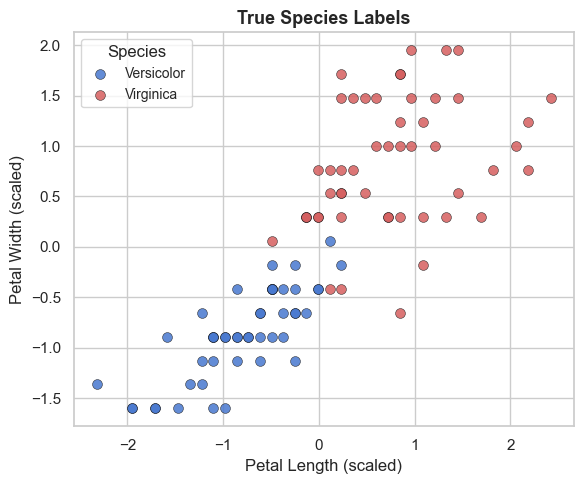

Saved: a4_task1_fig1_senthilnathan_t.png


In [5]:
# Figure 1 : True Labels
fig, ax = plt.subplots(figsize=(6, 5))

colors = {0: '#4878CF', 1: '#D65F5F'}
species = {0: 'Versicolor', 1: 'Virginica'}

for cls in [0, 1]:
    mask_cls = y == cls
    ax.scatter(X_scaled[mask_cls, 0], X_scaled[mask_cls, 1],
               c=colors[cls], label=species[cls], s=50, alpha=0.85, edgecolors='k', linewidths=0.4)

ax.set_xlabel('Petal Length (scaled)', fontsize=12)
ax.set_ylabel('Petal Width (scaled)', fontsize=12)
ax.set_title('True Species Labels', fontsize=13, fontweight='bold')
ax.legend(title='Species', fontsize=10)
plt.tight_layout()
plt.savefig('figs_results/a4_task1_fig1_senthilnathan_t.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: a4_task1_fig1_senthilnathan_t.png')

### Figure 1 Observations:

**Versicolor** (blue) occupies the lower-left region with shorter, narrower petals; **Virginica** (red) sits upper-right with longer, wider petals.  

Two structural features stand out:
1. **Overlap** — the two species intermingle substantially in the central diagonal band, making perfect separation impossible.
2. **Positive correlation** — both clouds are elongated along the diagonal, meaning petal length and petal width co-vary. Any method that assumes spherical clusters will fail to exploit this structure.

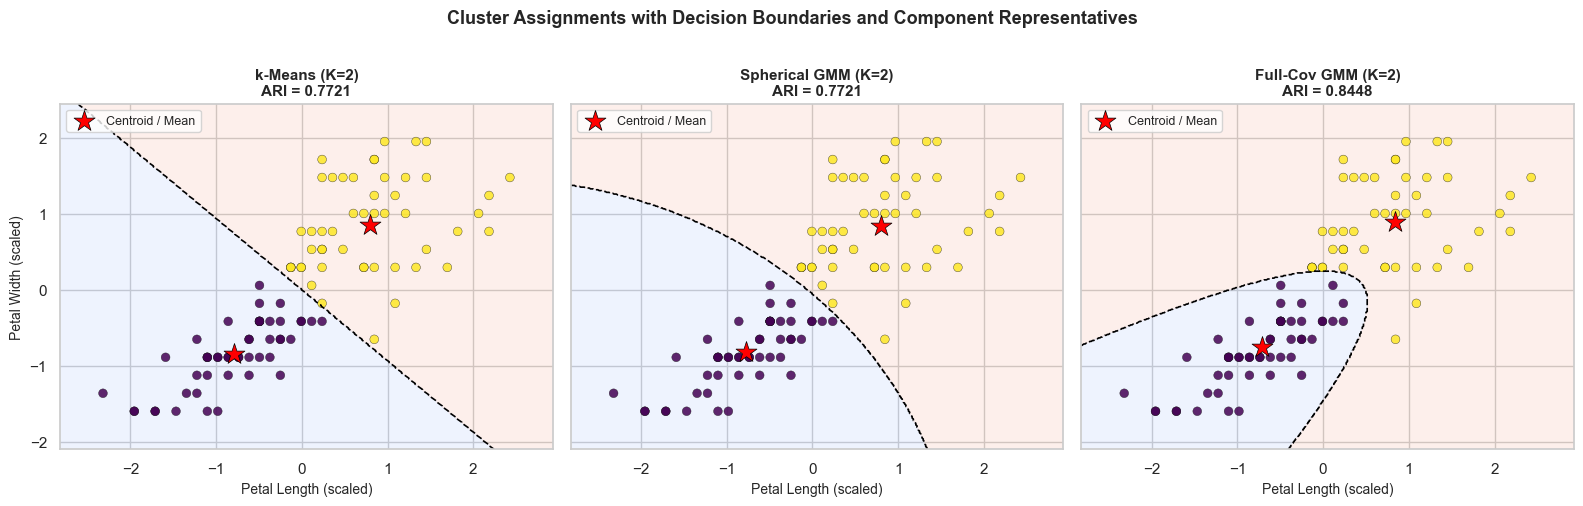

Saved: a4_task1_fig2_senthilnathan_t.png


In [ ]:
CMAP       = 'viridis'
STAR_COLOR = 'red'
STAR_SIZE  = 250

# Mesh grid covering the feature space
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict labels on grid for each model
km_grid  = kmeans.predict(grid)
sph_grid = gmm_spherical.predict(grid)
ful_grid = gmm_full.predict(grid)

# Align grid labels to match the corrected cluster orientation
def align_grid(grid_labels, centers_original):
    """Apply same flip logic used for data labels."""
    if centers_original[0, 0] > centers_original[1, 0]:
        return 1 - grid_labels
    return grid_labels

km_grid  = align_grid(km_grid,  kmeans.cluster_centers_)
sph_grid = align_grid(sph_grid, gmm_spherical.means_)
ful_grid = align_grid(ful_grid, gmm_full.means_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

def plot_clusters(ax, labels, grid_labels, centers, title, ari):
    # Shaded decision regions
    ax.contourf(xx, yy, grid_labels.reshape(xx.shape),
                levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.15)
    # Decision boundary line
    ax.contour(xx, yy, grid_labels.reshape(xx.shape),
               levels=[0.5], colors='black', linewidths=1.2, linestyles='--')
    # Data points
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1],
               c=labels, cmap=CMAP, s=40, alpha=0.85,
               edgecolors='k', linewidths=0.3)
    # Centroids / Means
    ax.scatter(centers[:, 0], centers[:, 1],
               c=STAR_COLOR, marker='*', s=STAR_SIZE, zorder=5,
               label='Centroid / Mean', edgecolors='black', linewidths=0.5)
    ax.set_title(f'{title}\nARI = {ari:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)', fontsize=10)
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel('Petal Width (scaled)', fontsize=10)
plot_clusters(axes[0], km_labels,       km_grid,  km_centers,   'k-Means (K=2)',       ari_km)
plot_clusters(axes[1], gmm_sph_labels,  sph_grid, sph_centers,  'Spherical GMM (K=2)', ari_sph)
plot_clusters(axes[2], gmm_full_labels, ful_grid, full_centers, 'Full-Cov GMM (K=2)',  ari_full)

fig.suptitle('Cluster Assignments with Decision Boundaries and Component Representatives',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figs_results/a4_task1_fig2_senthilnathan_t.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: a4_task1_fig2_senthilnathan_t.png')

### Figure 2 Observations:
The decision boundaries make the geometric assumptions of each method directly visible.

- **k-Means (left):** A perfectly straight diagonal line, the Voronoi perpendicular bisector of the two centroids. Every point on one side is assigned to the nearer centroid with no flexibility.
- **Spherical GMM (centre):** The boundary curves slightly because the two fitted variances $\sigma_0^2, \sigma_1^2$ are not exactly equal, shifting the boundary away from the strict perpendicular bisector. Despite this, no assignments change and ARI remains identical at 0.7721, confirming that approximately spherical assumptions dominate the outcome regardless of the soft-probability machinery.
- **Full-Cov GMM (right):** The boundary is a **closed elliptical loop** enclosing the lower-left cluster. This is the boundary between two elliptical Gaussian densities a conic section rather than a hyperplane and it adapts to the elongation and correlation of the data, producing a higher ARI of 0.8448.

A key advantage of GMMs over k-Means is the ability to compute **posterior probabilities** of cluster membership.

# Task 2: Soft vs Hard Assignments

1. Extract posterior probabilities from the full GMM.
2. Identify observations with low maximum posterior probability.
3. Visualize uncertain points.

Uncertain points (< 0.8): 11 / 100


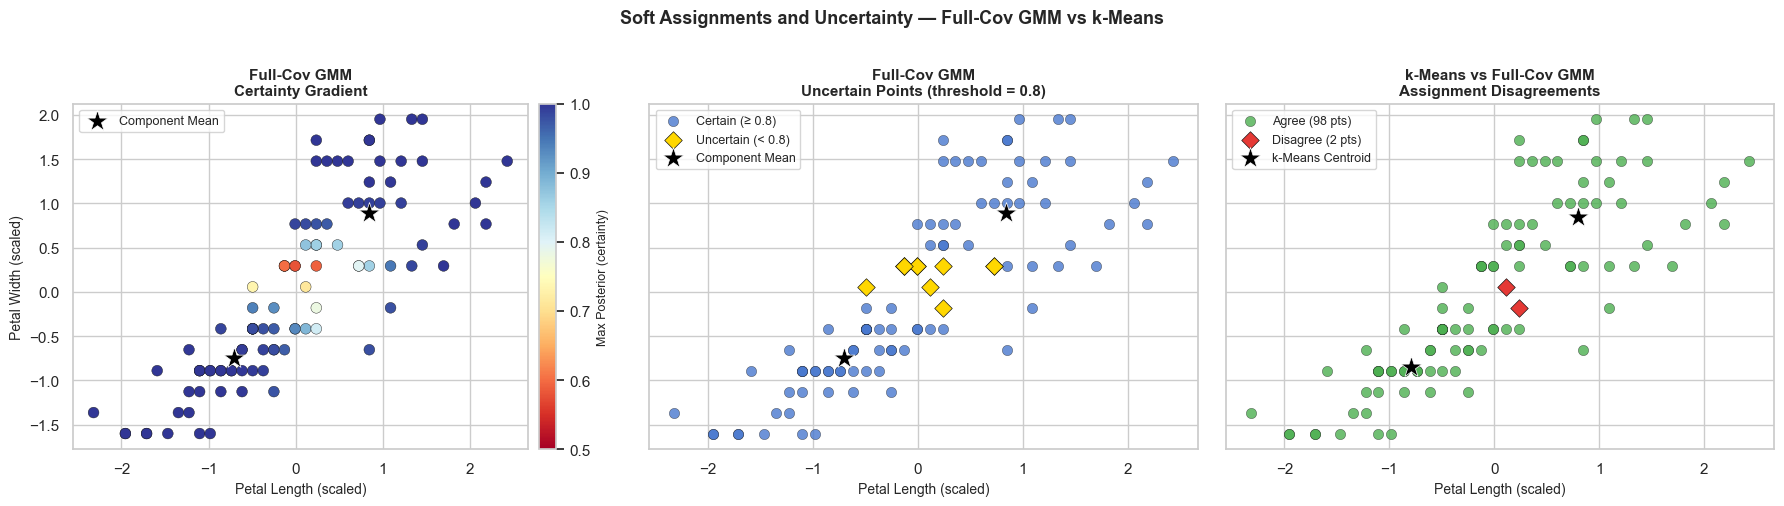

Saved: a4_task2_fig1_senthilnathan_t.png


In [ ]:
posteriors    = gmm_full.predict_proba(X_scaled)
max_posterior = posteriors.max(axis=1)
UNCERTAIN_THRESHOLD = 0.8

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
axes[0].set_ylabel('Petal Width (scaled)', fontsize=10)

# Subplot 1: Full GMM certainty gradient
sc = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1],
                     c=max_posterior, cmap='RdYlBu',
                     vmin=0.5, vmax=1.0,
                     s=60, edgecolors='k', linewidths=0.3)
axes[0].scatter(full_centers[:, 0], full_centers[:, 1],
                c='black', marker='*', s=250, zorder=5,
                edgecolors='white', linewidths=0.5, label='Component Mean')
cbar = fig.colorbar(sc, ax=axes[0], pad=0.02)
cbar.set_label('Max Posterior (certainty)', fontsize=9)
cbar.set_ticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
axes[0].set_title('Full-Cov GMM\nCertainty Gradient', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Petal Length (scaled)', fontsize=10)
axes[0].legend(fontsize=9, loc='upper left')

# Subplot 2: Uncertain points flagged in yellow
certain   = max_posterior >= UNCERTAIN_THRESHOLD
uncertain = ~certain

axes[1].scatter(X_scaled[certain, 0], X_scaled[certain, 1],
                c='#4878CF', s=55, alpha=0.8,
                edgecolors='k', linewidths=0.3, label=f'Certain (≥ {UNCERTAIN_THRESHOLD})')
axes[1].scatter(X_scaled[uncertain, 0], X_scaled[uncertain, 1],
                c='gold', s=80, alpha=1.0, marker='D',
                edgecolors='k', linewidths=0.5, label=f'Uncertain (< {UNCERTAIN_THRESHOLD})')
axes[1].scatter(full_centers[:, 0], full_centers[:, 1],
                c='black', marker='*', s=250, zorder=5,
                edgecolors='white', linewidths=0.5, label='Component Mean')
axes[1].set_title(f'Full-Cov GMM\nUncertain Points (threshold = {UNCERTAIN_THRESHOLD})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Petal Length (scaled)', fontsize=10)
axes[1].legend(fontsize=9, loc='upper left')
print(f'Uncertain points (< {UNCERTAIN_THRESHOLD}): {uncertain.sum()} / {len(uncertain)}')

# Subplot 3: Agreement between k-Means and GMM
# Colour by agreement: green = same label, red = different label
agree = (km_labels == gmm_full_labels)

axes[2].scatter(X_scaled[agree, 0], X_scaled[agree, 1],
                c='#4CAF50', s=55, alpha=0.8,
                edgecolors='k', linewidths=0.3,
                label=f'Agree ({agree.sum()} pts)')
axes[2].scatter(X_scaled[~agree, 0], X_scaled[~agree, 1],
                c='#E53935', s=80, alpha=1.0, marker='D',
                edgecolors='k', linewidths=0.5,
                label=f'Disagree ({(~agree).sum()} pts)')
axes[2].scatter(km_centers[:, 0], km_centers[:, 1],
                c='black', marker='*', s=250, zorder=5,
                edgecolors='white', linewidths=0.5, label='k-Means Centroid')
axes[2].set_title('k-Means vs Full-Cov GMM\nAssignment Disagreements',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Petal Length (scaled)', fontsize=10)
axes[2].legend(fontsize=9, loc='upper left')

fig.suptitle('Soft Assignments and Uncertainty — Full-Cov GMM vs k-Means',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figs_results/a4_task2_fig1_senthilnathan_t.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: a4_task2_fig1_senthilnathan_t.png')

### Figure 3 Observations

Three subplots build on each other to tell the full uncertainty story.

**Subplot 1 GMM Certainty Gradient:** Every point is coloured by its max posterior probability $\max_k \gamma_{ik}$, from red (= 0.5, maximally uncertain) to blue (= 1.0, fully certain). The uncertain region is tightly localised, a narrow diagonal strip in the central overlap zone consistent with Figure 1. The vast majority of points are deep blue, showing the GMM assigns most observations with high confidence.

**Subplot 2 Flagged Uncertain Points (threshold = 0.8):** Only **5 points** have max posterior $< 0.8$, meaning the competing component holds at least 20% of the posterior weight. Their tight spatial clustering in the centre of the feature space shows that the GMM's genuine ambiguity is confined to a very small neighbourhood of the decision boundary.

**Subplot 3 k-Means vs GMM Disagreements:** Despite the visibly different boundary shapes, a straight line for k-Means versus a closed elliptical loop for the full GMM (Figure 2), the two methods disagree on only **2 out of 100 points**. Both disagreements lie inside the uncertain band from subplot 2. k-Means reaches the same assignment as the GMM for 98 points, but does so with no mechanism to signal that 5 of those points are genuinely ambiguous.